# spin_funnel_prototype v1

### Prototype pulse sequence for the spin funnel experiment, utilizing the sequence_helper library

Connect:
- QCM out 0 to oscilloscope
- QCM out 1 to oscillocsope

Authors: Kyle MacRobbie, Ben Van Osch

---

### Setup

In [8]:
# Imports
import matplotlib.pyplot as plt
import pyvisa
import numpy as np
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument
from qblox_instruments import Cluster, ClusterType
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module
import sys
sys.path.append(r"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Libraries\\Qblox Sequence Helper")
import sequence_helper as sh

In [9]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'
# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True
    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]
cluster.reset()
print(cluster.get_system_status())
qrm_module = modules[4]
qcm_module = modules[2]
rf_module = modules[6]
rm = pyvisa.ResourceManager()
scope = rm.open_resource('GPIB0::8::INSTR')

Status: OKAY, Flags: NONE, Slot flags: NONE


In [3]:
# Setting the oscilloscope ranges
scope.write(f'TIME_DIV {5000e-9} S')	# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.01} V')	# Set the voltage scale on channel 1
scope.write(f'C2:VOLT_DIV {0.01} V')	# Set the voltage scale on channel 2
scope.write(f'C3:VOLT_DIV {0.5} V')	    # Set the voltage scale on channel 2
scope.write(f'C4:VOLT_DIV {1.5} V')	    # Set the voltage scale on channel 2
scope.write(f'TRIG_DELAY {0}')			# Set the time scale left/right on the display
scope.write(f'TRIG_MODE NORMAL')		# Set the trigger mode to "single" in order to take one acquisition

18

---

### Sequence

In [4]:
def run_spin_funnel_sequence(offs11, offs12, offs13, offs21, offs22, offs23, ramp_length, gate_pulse_length):
	# Define steps
	steps_out0 = [
		['square', gate_pulse_length, offs11],
		['ramp', ramp_length, offs11, offs12],
		['square', gate_pulse_length, offs12],
		['ramp', ramp_length, offs12, offs13],
		['square', gate_pulse_length, offs13],
		['ramp', ramp_length, offs13, offs11]
	]
	steps_out1 = [
		['square', gate_pulse_length, offs21],
		['ramp', ramp_length, offs21, offs22],
		['square', gate_pulse_length, offs22],
		['ramp', ramp_length, offs22, offs23],
		['square', gate_pulse_length, offs23],
		['ramp', ramp_length, offs23, offs21]
	]
	steps_in = ['acq', 0, (gate_pulse_length * 3) + (ramp_length * 3)]

	# Set number of Q1ASM loops
	num_loops = 1000

	# Disconnect all outputs
	sh.disconnect_io(qcm_module)
	sh.disconnect_io(qrm_module)

	# Upload sequences to their respective sequencers
	qcm_module.sequencer0.sequence(sh.make_output_sequence(input = steps_out0, module = 'qcm', iterations = num_loops))
	qcm_module.sequencer1.sequence(sh.make_output_sequence(input = steps_out1, module = 'qcm', iterations = num_loops))
	qrm_module.sequencer0.sequence(sh.make_input_sequence(input = steps_in, iterations = num_loops, resolution = 300))
	qrm_module.sequencer1.sequence(sh.make_input_sequence(input = steps_in, iterations = num_loops, resolution = 300))

	# Connect outputs
	sh.connect_output(module = qcm_module, sequencer = 0, output_index = 0, path = 0)
	sh.connect_output(module = qcm_module, sequencer = 1, output_index = 1, path = 0)
	sh.connect_input(module = qrm_module, sequencer = 0, input_index = 0, path = 0, resolution = 300)
	sh.connect_input(module = qrm_module, sequencer = 1, input_index = 1, path = 1, resolution = 300)

	# Correcting input offset
	qrm_module.in0_offset(-0.015)
	qrm_module.in1_offset(-0.0075)

	# Arm sequencers
	qcm_module.arm_sequencer(0)
	qcm_module.arm_sequencer(1)
	qrm_module.arm_sequencer(0)
	qrm_module.arm_sequencer(1)

	# Start sequencer
	cluster.start_sequencer()

	# Get the acquisition data
	qrm_module.get_acquisition_status(0) # Wait for the sequencer to stop with a timeout period of one minute.
	qrm_module.store_scope_acquisition(0, 'acq') # Move acquisition data from temporary memory to acquisition list.
	data0 = qrm_module.get_acquisitions(0) # Get acquisition list from instrument.

	return data0

In [5]:
# Set up gate voltages for different steps
# Set DC source to have out 0,0 at -0.3175,-0.3025
offs11_ = 0		# V	# Offset for gate 1 step 1
offs12_ = np.linspace(-0.321, -0.315, 10)
offs13_ = 0.01	# V	# Offset for gate 1 step 3

offs21_ = 0		# V	# Offset for gate 1 step 1
offs22_ = (-2 / 3) * offs12_ - 0.5 
offs23_ = 0.0075	# V	# Offset for gate 1 step 3

# Adjust for offset
offs12_ += 0.3175
offs22_ += 0.3025

# Set up pulse times
ramp_length_ = 200 		 # ns
gate_pulse_length_ = 5000 # ns

for i in range(len(offs12_)):
	readout_data = run_spin_funnel_sequence(offs11_, offs12_[i], offs13_, offs21_, offs22_[i], offs23_, ramp_length_, gate_pulse_length_)

	# Extract and save the scope data to a text file
	readout0 = readout_data['acq']['acquisition']['scope']['path0']['data']
	readout1 = readout_data['acq']['acquisition']['scope']['path1']['data']

	# Saving the data to text files
	name = f"step{i} path0"
	file = open(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Experiments\\Spin Funnel\\Simulation data\\{name}.txt", "w")
	data_text = ""
	for point in readout0:
		data_text += f"{str(point)}\n"
	file.write(data_text)
	file.close()
	name = f"step{i} path1"
	file = open(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Experiments\\Spin Funnel\\Simulation data\\{name}.txt", "w")
	data_text = ""
	for point in readout1:
		data_text += f"{str(point)}\n"
	file.write(data_text)
	file.close()

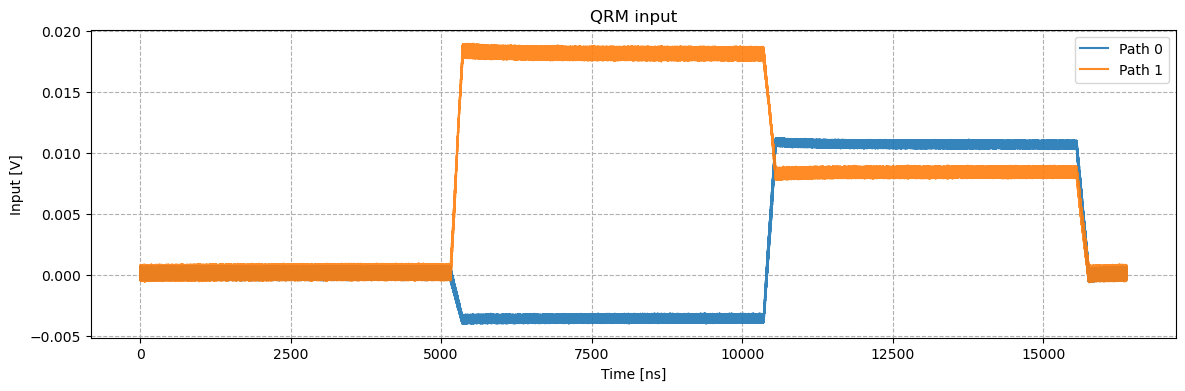

In [6]:
sh.plot_input(module = qrm_module, sequencer = 0, acquisition_name = 'acq', range = [0, 10000000000000])

---

### Stopping

In [11]:
# Stop and check status
cluster.stop_sequencer()
print("QCM sequencer 0:  " + str(qcm_module.get_sequencer_status(0)))
print("QCM sequencer 1:  " + str(qcm_module.get_sequencer_status(1)))
print("RF sequencer 1:   " + str(rf_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(0)))
print("QRM sequencer 1:  " + str(qrm_module.get_sequencer_status(1)))
cluster.reset()
print(cluster.get_system_status())

QCM sequencer 0:  Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
RF sequencer 1:   Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:  Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
